In [1]:
# Fire2Air Darwin — Model 3 Count Prediction and Explainability
# Name: Navodya Piumanthi

RANDOM_STATE = 42

In [2]:
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import PoissonRegressor, TweedieRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_poisson_deviance
)

In [4]:
try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
    print("XGBoost available")

except Exception as exc:
    HAS_XGBOOST = False
    print("XGBoost unavailable:", exc)

try:
    import shap
    HAS_SHAP = True
    print("SHAP available")

except Exception as exc:
    HAS_SHAP = False
    print("SHAP unavailable:", exc)

XGBoost available
SHAP available


In [5]:
RANDOM_STATE = 42

# Locate the Source code folder containing the shared modelling checkpoint
possible_folders = [
    Path.cwd(),
    Path.cwd() / "Source code",
    Path.cwd().parent,
    Path.cwd().parent / "Source code",
]

project_folder = None

for folder in possible_folders:
    folder = folder.resolve()

    if (
        (folder / "Fire2Air_model_ready_checkpoint.csv").exists()
        and (folder / "Fire2Air_feature_manifest.json").exists()
    ):
        project_folder = folder
        break

if project_folder is None:
    raise FileNotFoundError(
        "Could not find Fire2Air_model_ready_checkpoint.csv and "
        "Fire2Air_feature_manifest.json inside the Source code folder. "
        "Run the data-processing notebook first."
    )

print("Project folder:", project_folder)

Project folder: C:\Users\navod\Desktop\PRT661---DATA-SCIENCE-PRACTICE---Dan5---Theme2\Source code


In [6]:
output_root = project_folder / "outputs_prt661"
table_dir = output_root / "tables"
figure_dir = output_root / "figures"
model_dir = output_root / "models"

for folder in [table_dir, figure_dir, model_dir]:
    folder.mkdir(parents=True, exist_ok=True)

integrated_daily = pd.read_csv(
    project_folder / "Fire2Air_model_ready_checkpoint.csv",
    parse_dates=["date", "target_date"],
)

with open(
    project_folder / "Fire2Air_feature_manifest.json",
    "r",
    encoding="utf-8"
) as f:
    manifest = json.load(f)

model_features = manifest["features"]
duration_target = manifest["targets"]["count"]

print("Project folder:", project_folder)
print("Dataset shape:", integrated_daily.shape)
print("Model 3 target:", duration_target)

Project folder: C:\Users\navod\Desktop\PRT661---DATA-SCIENCE-PRACTICE---Dan5---Theme2\Source code
Dataset shape: (7530, 58)
Model 3 target: target_hours_ge_25_next_day


In [7]:
duration_data = integrated_daily.dropna(
    subset=[duration_target, "target_date"]
).copy()

duration_data["target_year"] = duration_data["target_date"].dt.year

train_duration = duration_data[
    duration_data["target_year"] <= 2022
].copy()

validation_duration = duration_data[
    duration_data["target_year"] == 2023
].copy()

test_duration = duration_data[
    duration_data["target_year"] == 2024
].copy()

print("Train rows:", len(train_duration))
print("Validation rows:", len(validation_duration))
print("Test rows:", len(test_duration))

Train rows: 2415
Validation rows: 661
Test rows: 645


In [8]:
if min(
    len(train_duration),
    len(validation_duration),
    len(test_duration)
) == 0:
    raise ValueError(
        f"Insufficient chronological data: "
        f"train={len(train_duration)}, "
        f"validation={len(validation_duration)}, "
        f"test={len(test_duration)}"
    )

assert (
    train_duration["target_date"].max()
    < validation_duration["target_date"].min()
)

assert (
    validation_duration["target_date"].max()
    < test_duration["target_date"].min()
)

assert duration_data[duration_target].between(0, 24).all()

print("\nTarget distribution:")
print(
    duration_data[duration_target]
    .describe()
    .round(3)
    .to_string()
)

print(
    "Zero-hour proportion:",
    round((duration_data[duration_target] == 0).mean(), 4)
)


Target distribution:
count    3721.000
mean        2.320
std         4.243
min         0.000
25%         0.000
50%         0.000
75%         3.000
max        24.000
Zero-hour proportion: 0.6192


In [9]:
X_train = train_duration[model_features]
y_train = train_duration[duration_target]

X_validation = validation_duration[model_features]
y_validation = validation_duration[duration_target]

X_test = test_duration[model_features]
y_test = test_duration[duration_target]

print("Training features:", X_train.shape)
print("Validation features:", X_validation.shape)
print("Test features:", X_test.shape)

Training features: (2415, 22)
Validation features: (661, 22)
Test features: (645, 22)


In [10]:
categorical_features = ["station"]
numeric_features = [
    feature
    for feature in model_features
    if feature not in categorical_features
]

def onehot():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False
        )

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot()),
])

count_preprocessor = ColumnTransformer([
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    ),
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]),
        numeric_features
    ),
])

tree_preprocessor = ColumnTransformer([
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    ),
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]),
        numeric_features
    ),
])

In [11]:
def bounded(predictions):
    return np.clip(
        np.asarray(predictions, dtype=float),
        0,
        24
    )

def count_metrics(y_true, predictions):
    pred = bounded(predictions)

    return {
        "MAE": mean_absolute_error(y_true, pred),
        "RMSE": float(
            np.sqrt(mean_squared_error(y_true, pred))
        ),
        "R2": r2_score(y_true, pred),
        "Mean_Poisson_Deviance": mean_poisson_deviance(
            y_true,
            np.clip(pred, 1e-6, None)
        ),
        "Prediction_Min": float(pred.min()),
        "Prediction_Max": float(pred.max()),
    }

In [12]:
configurations = [
    (
        "Poisson Regression",
        "alpha=0.1",
        Pipeline([
            ("preprocessor", count_preprocessor),
            ("model", PoissonRegressor(
                alpha=0.1,
                max_iter=1000
            )),
        ])
    ),
    (
        "Poisson Regression",
        "alpha=1.0",
        Pipeline([
            ("preprocessor", count_preprocessor),
            ("model", PoissonRegressor(
                alpha=1.0,
                max_iter=1000
            )),
        ])
    ),
    (
        "Tweedie Regression",
        "power=1.5;alpha=0.1",
        Pipeline([
            ("preprocessor", count_preprocessor),
            ("model", TweedieRegressor(
                power=1.5,
                alpha=0.1,
                link="log",
                max_iter=1000
            )),
        ])
    ),
    (
        "Tweedie Regression",
        "power=1.5;alpha=1.0",
        Pipeline([
            ("preprocessor", count_preprocessor),
            ("model", TweedieRegressor(
                power=1.5,
                alpha=1.0,
                link="log",
                max_iter=1000
            )),
        ])
    ),
]

In [13]:
for n_estimators, max_depth, min_samples_leaf in [
    (300, None, 1),
    (300, None, 4),
    (300, 10, 4),
    (300, 15, 4)
]:
    configurations.append((
        "Random Forest",
        (
            f"n_estimators={n_estimators};"
            f"max_depth={max_depth};"
            f"min_samples_leaf={min_samples_leaf}"
        ),
        Pipeline([
            ("preprocessor", tree_preprocessor),
            ("model", RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )),
        ])
    ))

In [14]:
if HAS_XGBOOST:
    for n_estimators, learning_rate, max_depth in [
        (100, 0.05, 2),
        (200, 0.05, 2),
        (300, 0.05, 2),
        (200, 0.05, 3)
    ]:
        configurations.append((
            "XGBoost Poisson",
            (
                f"n_estimators={n_estimators};"
                f"learning_rate={learning_rate};"
                f"max_depth={max_depth}"
            ),
            Pipeline([
                ("preprocessor", tree_preprocessor),
                ("model", XGBRegressor(
                    n_estimators=n_estimators,
                    learning_rate=learning_rate,
                    max_depth=max_depth,
                    objective="count:poisson",
                    eval_metric="poisson-nloglik",
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )),
            ])
        ))

In [15]:
validation_rows = []
model_templates = {}

for model_name, config_id, pipeline in configurations:
    pipeline.fit(X_train, y_train)

    raw_predictions = pipeline.predict(X_validation)

    metrics = count_metrics(
        y_validation,
        raw_predictions
    )

    validation_rows.append({
        "Model": model_name,
        "Config": config_id,
        "Raw_Negative_Predictions": int(
            (np.asarray(raw_predictions) < 0).sum()
        ),
        **metrics,
    })

    model_templates[(model_name, config_id)] = pipeline

validation_results = pd.DataFrame(
    validation_rows
).sort_values(
    ["MAE", "RMSE", "Mean_Poisson_Deviance"]
).reset_index(drop=True)

print("\n2023 count-model validation results:")
print(
    validation_results
    .round(4)
    .to_string(index=False)
)

validation_results.to_csv(
    table_dir / "model3_count_validation_results.csv",
    index=False
)

selected = validation_results.iloc[0]

best_model_name = selected["Model"]
best_config_id = selected["Config"]

selected_template = model_templates[
    (best_model_name, best_config_id)
]

print(
    "\nSelected count model by validation MAE:",
    best_model_name
)

print("Configuration:", best_config_id)


2023 count-model validation results:
             Model                                             Config  Raw_Negative_Predictions    MAE   RMSE     R2  Mean_Poisson_Deviance  Prediction_Min  Prediction_Max
Tweedie Regression                                power=1.5;alpha=0.1                         0 2.4908 4.2640 0.4396                 3.7436          0.0129         24.0000
   XGBoost Poisson    n_estimators=300;learning_rate=0.05;max_depth=2                         0 2.5052 4.4023 0.4026                 3.7583          0.0253         12.5686
   XGBoost Poisson    n_estimators=200;learning_rate=0.05;max_depth=3                         0 2.5126 4.4113 0.4002                 3.8249          0.0330         11.3745
Poisson Regression                                          alpha=0.1                         0 2.5167 4.1788 0.4617                 3.7086          0.0250         19.9248
     Random Forest   n_estimators=300;max_depth=10;min_samples_leaf=4                         0 2.5205

In [16]:
development_duration = pd.concat(
    [train_duration, validation_duration],
    ignore_index=True
)

X_development = development_duration[model_features]
y_development = development_duration[duration_target]

final_count_model = clone(selected_template)

final_count_model.fit(
    X_development,
    y_development
)

raw_test_predictions = final_count_model.predict(X_test)

test_predictions = bounded(raw_test_predictions)

final_metrics = count_metrics(
    y_test,
    raw_test_predictions
)

final_metrics.update({
    "Model": best_model_name,
    "Config": best_config_id,
    "Raw_Negative_Predictions": int(
        (np.asarray(raw_test_predictions) < 0).sum()
    ),
})

final_metrics_df = pd.DataFrame([final_metrics])

print("\nFinal 2024 count performance:")
print(
    final_metrics_df
    .round(4)
    .to_string(index=False)
)

final_metrics_df.to_csv(
    table_dir / "model3_final_2024_metrics.csv",
    index=False
)


Final 2024 count performance:
   MAE   RMSE     R2  Mean_Poisson_Deviance  Prediction_Min  Prediction_Max              Model              Config  Raw_Negative_Predictions
1.2622 2.1788 0.4502                 1.8056          0.0116         14.8632 Tweedie Regression power=1.5;alpha=0.1                         0


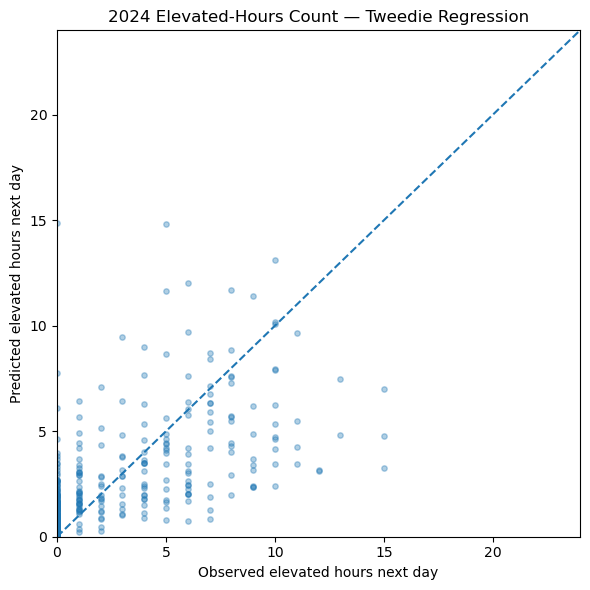

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    y_test,
    test_predictions,
    alpha=0.35,
    s=15
)

ax.plot(
    [0, 24],
    [0, 24],
    linestyle="--"
)

ax.set_xlim(0, 24)
ax.set_ylim(0, 24)

ax.set_xlabel("Observed elevated hours next day")
ax.set_ylabel("Predicted elevated hours next day")

ax.set_title(
    f"2024 Elevated-Hours Count — {best_model_name}"
)

fig.tight_layout()

fig.savefig(
    figure_dir / "model3_2024_observed_vs_predicted.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

Top 15 Model 3 permutation importances:
             feature  importance_mean  importance_std
           month_cos          0.23605         0.02670
           pm25_mean          0.13372         0.02357
            pm25_max          0.12817         0.00742
     frp_sum_0_500km          0.07224         0.00964
     nearest_fire_km          0.03859         0.01820
       humidity_mean          0.02402         0.01026
           month_sin          0.01756         0.01476
             station          0.00881         0.00712
           pm10_mean          0.00631         0.00657
     wind_speed_mean          0.00496         0.00197
 fire_count_50_100km          0.00439         0.00391
      pm25_3day_mean          0.00411         0.00443
fire_count_100_200km          0.00278         0.00140
           pm25_lag1          0.00205         0.00353
fire_count_200_500km          0.00165         0.00116


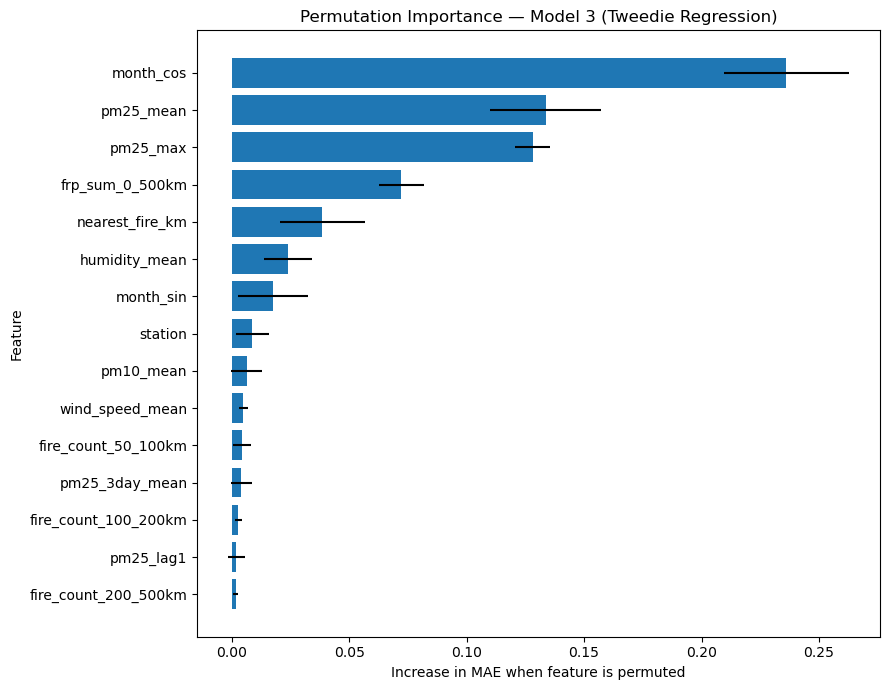

In [18]:


from sklearn.inspection import permutation_importance

perm = permutation_importance(
    final_count_model,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_df = (
    pd.DataFrame({
        "feature": model_features,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 Model 3 permutation importances:")
print(perm_df.head(15).round(5).to_string(index=False))

perm_df.to_csv(
    table_dir / "model3_count_permutation_importance.csv",
    index=False
)

top_perm = perm_df.head(15).sort_values("importance_mean")

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(
    top_perm["feature"],
    top_perm["importance_mean"],
    xerr=top_perm["importance_std"]
)

ax.set_xlabel("Increase in MAE when feature is permuted")
ax.set_ylabel("Feature")
ax.set_title(
    f"Permutation Importance — Model 3 ({best_model_name})"
)

fig.tight_layout()

fig.savefig(
    figure_dir / "model3_count_permutation_importance.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

Transformed feature count: 24


PermutationExplainer explainer: 81it [00:11,  7.14it/s]                         


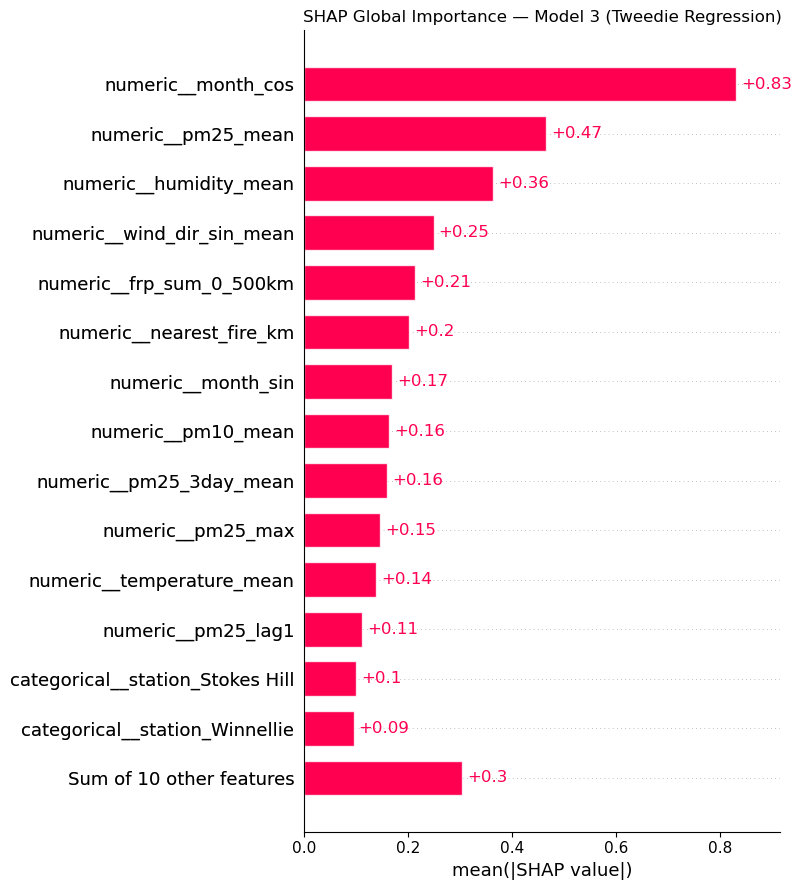

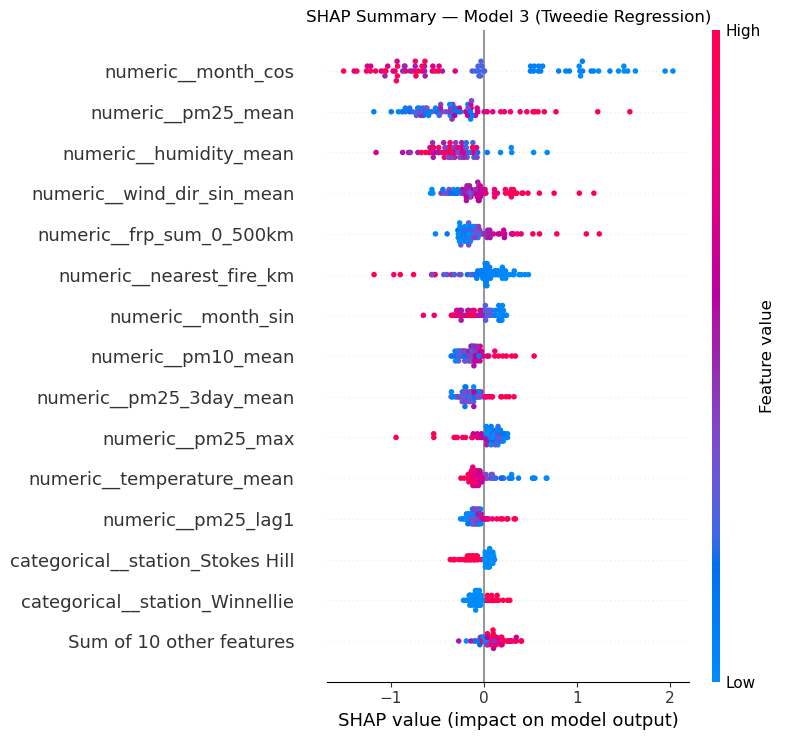

SHAP analysis completed successfully.


In [19]:
# ============================================================
# MODEL 3 — SHAP EXPLAINABILITY
# ============================================================

if HAS_SHAP:
    try:
        prep = final_count_model.named_steps["preprocessor"]
        estimator = final_count_model.named_steps["model"]

        # Small samples to keep SHAP calculation practical
        background_raw = X_development.sample(
            n=min(60, len(X_development)),
            random_state=RANDOM_STATE
        )

        explain_raw = X_test.sample(
            n=min(80, len(X_test)),
            random_state=RANDOM_STATE
        )

        background_t = prep.transform(background_raw)
        explain_t = prep.transform(explain_raw)

        # Convert sparse matrices if necessary
        if hasattr(background_t, "toarray"):
            background_t = background_t.toarray()

        if hasattr(explain_t, "toarray"):
            explain_t = explain_t.toarray()

        feature_names = prep.get_feature_names_out()

        print("Transformed feature count:", len(feature_names))

        explainer = shap.Explainer(
            estimator.predict,
            background_t,
            feature_names=feature_names,
            algorithm="permutation"
        )

        shap_values = explainer(
            explain_t,
            max_evals=2 * len(feature_names) + 1
        )

        # -----------------------------
        # SHAP global importance
        # -----------------------------

        shap.plots.bar(
            shap_values,
            max_display=15,
            show=False
        )

        plt.title(
            f"SHAP Global Importance — Model 3 ({best_model_name})"
        )

        plt.tight_layout()

        plt.savefig(
            figure_dir / "model3_shap_global_bar.png",
            dpi=180,
            bbox_inches="tight"
        )

        plt.show()

        # -----------------------------
        # SHAP beeswarm
        # -----------------------------

        shap.plots.beeswarm(
            shap_values,
            max_display=15,
            show=False
        )

        plt.title(
            f"SHAP Summary — Model 3 ({best_model_name})"
        )

        plt.tight_layout()

        plt.savefig(
            figure_dir / "model3_shap_beeswarm.png",
            dpi=180,
            bbox_inches="tight"
        )

        plt.show()

        print("SHAP analysis completed successfully.")

    except Exception as exc:
        print("SHAP could not complete:")
        print(repr(exc))

else:
    print("SHAP is not available.")